> **Data required:** This notebook uses InSight HP³ data from Spohn et al. (2024). 
> If you haven't already, download the datasets from [FigShare](https://doi.org/10.6084/m9.figshare.25099754) 
> and place them in `resources/data/`. See [`resources/data/README.md`](../resources/data/README.md) for details.

# Inverse Kappa Conclusions

Experiment 1: Single learnable κ, equal loss weights

- κ drifted to 1.01e-7 (2.5× Spohn's value)
- Surface fit was terrible (RMSE 19 K)
- Diagnosis: optimizer exploited the residual form ∂T/∂t / κ_eff, inflating κ to trivially shrink the physics loss without solving the equation correctly

Experiment 2: Single learnable κ, strong BC weighting (λ_BC=100, λ_data=50)

- κ converged to 4.19e-8 m²/s (~7% above Spohn's 3.93e-8)
- Surface fit excellent (RMSE 0.58 K)
- Mole fit still poor (RMSE 2.63 K) with clear phase lag
- Conclusion: independently validated Spohn's measurement, but constant κ insufficient to capture the mole signal

Experiment 3: Three piecewise κ values, same weights, mole at 9.4 cm

- κ values barely differentiated (4.50, 4.00, 3.72 × 10⁻⁸)
- Phase lag essentially unchanged
- Conclusion: depth-dependent κ alone doesn't fix the phase mismatch

Experiment 4: Three piecewise κ, mole depth changed to 1.7 cm

- κ values crashed to ~7-8 × 10⁻⁹ (5× too small)
- Phase corrected but amplitude wildly wrong (RMSE 6.68 K)
- Diagnosis: at 1.7 cm the physics demands ~60% of surface amplitude, but the real TEM-A averages over the full mole and shows much smaller amplitude. This creates an irreconcilable contradiction.
Key open question: Is the mole depth issue truly the bottleneck, or are we overlooking something else? The jump from 9.4 cm to 1.7 cm was based on the skin depth argument — that the diurnal signal is dominated by the shallowest part. But the TEM-A is a physical average over the mole, not a reading from just the shallow end.
What we're confident about:
- The single-κ recovery agreeing with Spohn is solid
- The 1D heat equation with constant κ can't fully capture the mole signal
- The mole data representation is currently our biggest modelling weakness
What needs more thought:
- Is 9.4 cm actually defensible for some reason we dismissed too quickly?
- Should we model the spatial averaging explicitly rather than guessing a single depth?

I cant make depth just another learnable parameter because that justs making too many compromises. What should I do from here? is there something I didnt consider? Analyse this thouroghly and give an honest and objective conclusion

In [1]:
from PIL import Image

import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import openpyxl
import optax

import jax.numpy as jnp

import copy

# Problem parameters
kappa = 3.93e-8       # thermal diffusivity [m^2/s]. Intial guess for the inverse problem (Spohn's value). We will learn this parameter.
depth = 0.4           # domain depth [m]
sol_seconds = 88775.244  # one sol [s]

avg_bottom_temp = 225.6  # average bottom temperature (K)
mole_depth = 0.017  # representative depth for diurnal signal [m]

# Surface bounadries. use Spohn's estimates for the depth of the duricrust and sand layers. We will learn the thermal diffusivity of each layer from the data, but we will keep the layer boundaries fixed for this example.
boundary_1 = 0.02  # duricrust --> sand  (top 2 cm)
boundary_2 = 0.12   # sand --> gravel/sand mixture (12 cm)

b1_normalized = boundary_1 / depth
b2_normalized = boundary_2 / depth

# TEM-A Sol 1202 = mole temperature over one sol (the warmest sol sampled)
# RAD Sol 511   = surface temperature from radiometer (Spohn's proxy for sol 1202)

wb_diurnal = openpyxl.load_workbook(
    '../resources/data/Mars Soil Temperatures and Thermal Properties from Diurnal Wave data.xlsx',
    data_only=True
)

# --- Mole temperature (TEM-A Sol 1202) ---
ws_tem = wb_diurnal['TEM-A Sol 1202']
ltst_mole, temp_mole = [], []
for row in ws_tem.iter_rows(min_row=2, values_only=True):
    # Column index 6 = 'LTST Conversion step 2' (hours, 0-24)
    # Column index 7 = 'average T15, T16' (Kelvin)
    ltst_val = row[6]
    temp_val = row[7]
    if ltst_val is not None and temp_val is not None:
        try:
            t = float(ltst_val)
            T = float(temp_val)
            if 0 <= t <= 24 and 200 < T < 260:
                ltst_mole.append(t)
                temp_mole.append(T)
        except (ValueError, TypeError):
            pass


# --- Surface temperature (RAD Sol 511) ---
ws_rad = wb_diurnal['RAD SOL 511 D']
ltst_surf, temp_surf = [], []
for row in ws_rad.iter_rows(min_row=2, values_only=True):
    # Column index 4 = 'LTST converted' (hours)
    # Column index 5 = 'FOV 2 Temperature converted' (Kelvin)
    try:
        t = float(row[4])
        T = float(row[5])
        if 0 <= t <= 24 and 150 < T < 350:
            ltst_surf.append(t)
            temp_surf.append(T)
    except (ValueError, TypeError):
        pass

# Sort surface data by LTST (it may not be in order)
sorted_surf = sorted(zip(ltst_surf, temp_surf))
ltst_surf = [x[0] for x in sorted_surf]
temp_surf = [x[1] for x in sorted_surf]

# Conversion from hours to seconds for the time points. Make sure it is mapped correctly to the Mars sol time (0-88775.244 seconds)
ltst_mole = [t * sol_seconds / 24 for t in ltst_mole]
ltst_surf = [t * sol_seconds / 24 for t in ltst_surf]


# 1. Boundary Condition points (552 points each edge as we have 552 time points in the surface data)
n_surface = len(ltst_surf)  # Should be 552

# Surface boundary (x=0):
t_bc_surface = jnp.array(ltst_surf).reshape(-1, 1)  # (552, 1)
x_bc_surface = jnp.zeros((n_surface, 1))  # (552, 1)

u_bc_surface = jnp.array(temp_surf).reshape(-1, 1)  # (552, 1)

# Bottom boundary (x=depth):
t_bc_bottom = jnp.linspace(0, sol_seconds, n_surface).reshape(-1, 1)  # (552, 1)
x_bc_bottom = jnp.ones((n_surface, 1)) * depth

u_bc_bottom = jnp.ones((n_surface, 1)) * avg_bottom_temp  # (552, 1)

# Combine them:
t_bc = jnp.concatenate([t_bc_surface, t_bc_bottom])
x_bc = jnp.concatenate([x_bc_surface, x_bc_bottom])
u_bc = jnp.concatenate([u_bc_surface, u_bc_bottom])


# 2. Physics collocation points (100 * 100 = 10,000 points)
key = random.PRNGKey(0)
key1, key2 = random.split(key)
t_physics = random.uniform(key1, (10000, 1), minval=0, maxval=sol_seconds)
x_physics = random.uniform(key2, (10000, 1), minval=0, maxval=depth)


# 3. Data points for Data Loss (5550 points)
# We can use the mole temperature data as additional data points inside the domain (not just at the boundaries). This will help guide the network to learn the correct solution.

t_data = jnp.array(ltst_mole).reshape(-1, 1)
x_data = jnp.ones((len(ltst_mole), 1)) * mole_depth
u_data = jnp.array(temp_mole).reshape(-1, 1)


# Normalise the data so the network only sees values of order 1. This helps with training stability and convergence. We will need to un-normalise the predictions later to compare with the original data.

# Normalisation parameters
t_min, t_max = 0.0, sol_seconds
x_min, x_max = 0.0, depth
u_min, u_max = 185.0, 300.0  # Based on the range of temperatures in the data

def normalize_t(t): return ( t - t_min) / (t_max - t_min)
def normalize_x(x): return ( x - x_min) / (x_max - x_min)
def normalize_u(u): return ( u - u_min) / (u_max - u_min)

def unnormalize_u(u_norm): return u_norm * (u_max - u_min) + u_min

# Normalize all data
t_bc = normalize_t(t_bc)
x_bc = normalize_x(x_bc)
u_bc = normalize_u(u_bc)

t_physics = normalize_t(t_physics)
x_physics = normalize_x(x_physics)

t_data = normalize_t(t_data)
x_data = normalize_x(x_data)
u_data = normalize_u(u_data)

#Normalize kappa as well (since it appears in the physics residual)
def normalize_kappa(kappa):
    return kappa * (t_max - t_min) / ((x_max - x_min)**2)


# Calculate kappa for different depths. Use sigmoid to ensure smooth transition between layers.
def kappa_eff(params, x):

    w = 0.01 # Transition width (in normalized x units)

    kappa_1 = normalize_kappa(jnp.exp(params['log_kappa_1']))  # Duricrust
    kappa_2 = normalize_kappa(jnp.exp(params['log_kappa_2']))  # Sand layer
    kappa_3 = normalize_kappa(jnp.exp(params['log_kappa_3']))  # Gravel/sand mixture
    
    # Smooth transition using sigmoid functions
    transition_1 = jax.nn.sigmoid((x - b1_normalized) / w)  # Transition from layer 1 to layer 2
    transition_2 = jax.nn.sigmoid((x - b2_normalized) / w)  # Transition from layer 2 to layer 3
    
    kappa_eff = kappa_1 * (1 - transition_1) + kappa_2 * (transition_1 - transition_2) + kappa_3 * transition_2
    return kappa_eff

# Neural Network

def init_network_params(layer_sizes, key):
    """
    Initialize parameters for a fully connected network.
    
    Args:
        layer_sizes: List of layer sizes, e.g., [2, 32, 32, 32, 1]
                    (input_dim, hidden1, hidden2, hidden3, output_dim)
        key: JAX random key for initialization
        
    Returns:
        params: idctionary containging the network list of dictionaries and log_kappa
    """
    # Split random key for each layer
    keys = random.split(key, len(layer_sizes))

    params = {}
    
    network = []
    for i in range(len(layer_sizes) - 1):
        n_in = layer_sizes[i]
        n_out = layer_sizes[i + 1]
        
        # Split key for weights and biases
        w_key, b_key = random.split(keys[i])
        
        # Xavier initialization for weights
        network.append({
            'w': random.normal(w_key, (n_in, n_out)) * jnp.sqrt(2.0 / n_in),
            'b': jnp.zeros(n_out)
        })
    
    params['network'] = network
    # Threee different kappa values for the layers of the soil structure: duricrust top, sand layer and gravel/sand mixture. We will learn these three parameters from the data.
    params['log_kappa_1'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity
    params['log_kappa_2'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity
    params['log_kappa_3'] = jnp.log(kappa)  # Learn log(kappa) to ensure positivity

    return params


def network(params, x):
    """
    Forward pass through the network.
    
    Args:
        params: List of layer parameters (from init_network_params)
        x: Input array, shape (batch_size, input_dim)
        
    Returns:
        Output array, shape (batch_size, output_dim)
    """
    # Process all hidden layers (all but last)
    

    for layer in params['network'][:-1]:
        # Linear transformation: x @ W + b
        x = jnp.dot(x, layer['w']) + layer['b']
        # Activation function
        x = jnp.tanh(x)
    
    # Output layer (no activation)
    final_layer = params['network'][-1]
    x = jnp.dot(x, final_layer['w']) + final_layer['b']
    
    return x


# Calculate Residual

def physics_residual_single(params, t_point, x_point):

    def u(t_val, x_val):
        tx_in = jnp.array([[t_val, x_val]])
        return network(params, tx_in)[0, 0]
    
    du_dt = grad(u, argnums=0)(t_point, x_point)

    d2u_dx2 = grad(grad(u, argnums = 1), argnums=1)(t_point, x_point)

    k_eff = kappa_eff(params, x_point)

    return du_dt / k_eff - d2u_dx2


# Vectorize to handle all physics points at once
# So vmap will call physics_residual_single 10000 times, once for each (t, x) pair, keeping params fixed.
physics_residual_batch = vmap(physics_residual_single, in_axes=(None, 0, 0))


# Initialize network
key = random.PRNGKey(123)
layer_sizes = [2, 64, 64, 64, 64, 1]  # 2 inputs (t, x), 1 output (u)
params = init_network_params(layer_sizes, key)

# Initialize optimizer
learning_rate = 1e-3
schedule = optax.piecewise_constant_schedule(init_value=learning_rate, boundaries_and_scales={60000: 0.1})
optimizer = optax.adam(learning_rate)
opt_state = optimizer.init(params)


@jit
def update_step(params, opt_state,
                t_bc, x_bc, u_bc, t_physics, x_physics, t_data, x_data, u_data):

    def loss_fn(params):
        
        # 1. Boundary Condition Loss
        tx_bc = jnp.concatenate([t_bc, x_bc], axis=1)
        u_pred_bc = network(params, tx_bc)
        bc_loss = jnp.mean((u_pred_bc - u_bc)**2)
        
        # 2. Physics Loss
        physics_residuals = physics_residual_batch(params, 
                                                t_physics.ravel(), # (10000,) not (10000, 1)
                                                x_physics.ravel()) # (10000,) not (10000, 1)
        physics_loss = jnp.mean(physics_residuals**2) # Physics residual is of 10000 points.

        # 3. Data Loss
        tx_data = jnp.concatenate([t_data, x_data], axis=1)
        u_pred_data = network(params, tx_data)
        data_loss = jnp.mean((u_pred_data - u_data)**2)
        
        return  bc_loss * 100 + physics_loss + data_loss * 50, (bc_loss, physics_loss, data_loss)
    
        # Compute loss and gradients
    (loss_val, individual_loss), grads = jax.value_and_grad(loss_fn, has_aux=True)(params)
    
    # Update parameters
    updates, new_opt_state = optimizer.update(grads, opt_state, params)
    new_params = optax.apply_updates(params, updates)
    
    return new_params, new_opt_state, loss_val, individual_loss


# Training parameters
num_iterations = 120000
save_every = 150  # Save every 150 iterations
print_every = 1000

# Storage for snapshots
snapshots = []
snapshot_iterations = []

# Prepare physics points (flatten for vmap)
t_phys_flat = t_physics.ravel()
x_phys_flat = x_physics.ravel()

# Training loop
losses = []
losses_bc = []
losses_phys = []
losses_data = []
for i in range(num_iterations):
    params, opt_state, loss, individual_loss = update_step(
        params, opt_state,
        t_bc, x_bc, u_bc,
        t_phys_flat, x_phys_flat,
        t_data, x_data, u_data
    )
    
    losses.append(loss)
    losses_bc.append(individual_loss[0])
    losses_phys.append(individual_loss[1])
    losses_data.append(individual_loss[2])


    # Save snapshot every 150 iterations
    if (i + 1) % save_every == 0:
        # Make a copy of params (important!)
        snapshots.append(copy.deepcopy(params))
        snapshot_iterations.append(i + 1)

    
    if (i + 1) % print_every == 0:
        print(f"Iteration {i+1}/{num_iterations}, Loss: {loss:.6f}")
        print(f"  BC Loss: {individual_loss[0]:.6f}, Physics Loss: {individual_loss[1]:.6f}, Data Loss: {individual_loss[2]:.6f}")
        print(f"  Current kappa 1: {jnp.exp(params['log_kappa_1']):.2e} m^2/s")
        print(f"  Current kappa 2: {jnp.exp(params['log_kappa_2']):.2e} m^2/s")
        print(f"  Current kappa 3: {jnp.exp(params['log_kappa_3']):.2e} m^2/s")





/mnt/c/ai-in-physics/cfd-ai-journey/.venv-linux/lib/python3.12/site-packages/openpyxl/reader/drawings.py:67: UserWarning: wmf image format is not supported so the image is being dropped
  warn(msg)


Iteration 1000/120000, Loss: 5.104806
  BC Loss: 0.048938, Physics Loss: 0.184003, Data Loss: 0.000539
  Current kappa 1: 4.01e-08 m^2/s
  Current kappa 2: 3.99e-08 m^2/s
  Current kappa 3: 3.99e-08 m^2/s
Iteration 2000/120000, Loss: 4.471427
  BC Loss: 0.041985, Physics Loss: 0.156982, Data Loss: 0.002318
  Current kappa 1: 4.10e-08 m^2/s
  Current kappa 2: 3.99e-08 m^2/s
  Current kappa 3: 3.99e-08 m^2/s
Iteration 3000/120000, Loss: 3.709858
  BC Loss: 0.033250, Physics Loss: 0.177705, Data Loss: 0.004143
  Current kappa 1: 4.26e-08 m^2/s
  Current kappa 2: 3.99e-08 m^2/s
  Current kappa 3: 3.99e-08 m^2/s
Iteration 4000/120000, Loss: 2.361090
  BC Loss: 0.017779, Physics Loss: 0.129284, Data Loss: 0.009079
  Current kappa 1: 4.44e-08 m^2/s
  Current kappa 2: 4.00e-08 m^2/s
  Current kappa 3: 3.99e-08 m^2/s
Iteration 5000/120000, Loss: 1.642965
  BC Loss: 0.009432, Physics Loss: 0.050675, Data Loss: 0.012981
  Current kappa 1: 4.43e-08 m^2/s
  Current kappa 2: 3.99e-08 m^2/s
  Current

## Compare PINN with Data

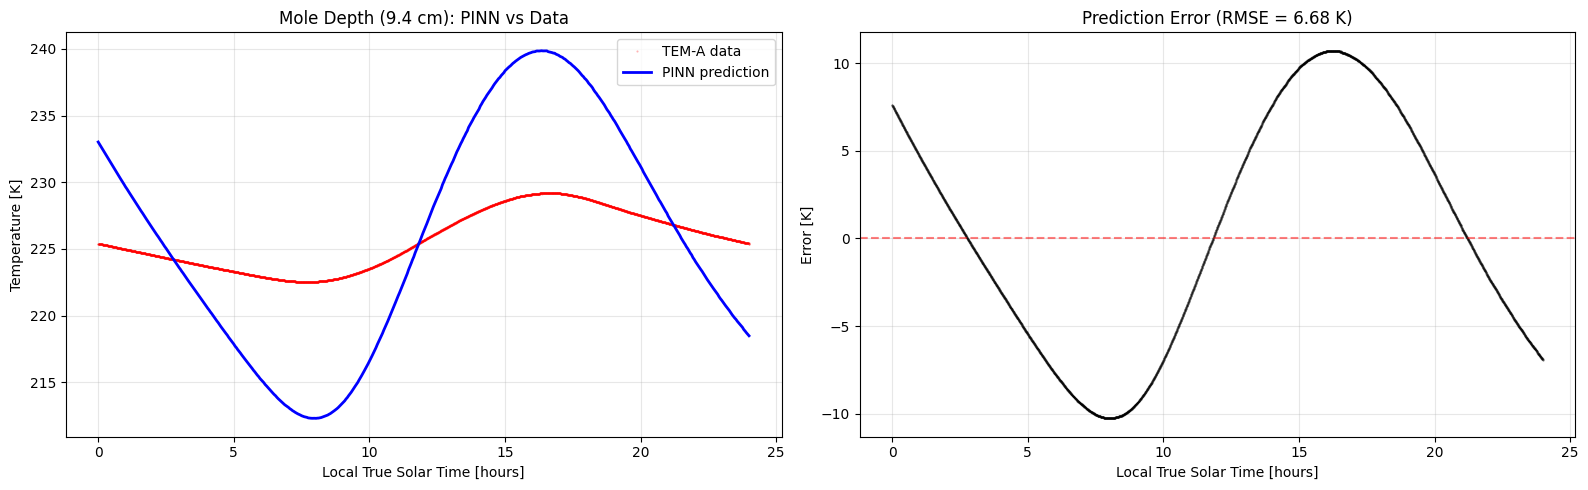

In [2]:
# ============================================================
# Plot: Network prediction vs TEM-A data at mole depth
# ============================================================

# Create a dense time array at the mole depth (normalised)
t_plot = jnp.linspace(0, 1, 500).reshape(-1, 1)  # normalised time [0,1]
x_plot = jnp.ones((500, 1)) * normalize_x(mole_depth)  # normalised mole depth

# Network prediction (normalised)
tx_plot = jnp.concatenate([t_plot, x_plot], axis=1)
u_pred_norm = network(params, tx_plot)

# Convert back to physical units
t_plot_hours = np.array(t_plot.ravel()) * 24  # back to LTST hours
u_pred_K = np.array(unnormalize_u(u_pred_norm.ravel()))  # back to Kelvin

# Also convert mole data back to hours for comparison
t_mole_hours = np.array(ltst_mole) * 24 / sol_seconds * (24/24)  
# Actually ltst_mole is already in seconds (converted earlier), so:
t_mole_hours = np.array(ltst_mole) / sol_seconds * 24  # seconds -> LTST hours
u_mole_K = np.array(temp_mole)  # already in Kelvin

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Left: overlay prediction and data
ax1 = axes[0]
ax1.plot(t_mole_hours, u_mole_K, 'r.', markersize=1, alpha=0.3, label='TEM-A data')
ax1.plot(t_plot_hours, u_pred_K, 'b-', linewidth=2, label='PINN prediction')
ax1.set_xlabel('Local True Solar Time [hours]')
ax1.set_ylabel('Temperature [K]')
ax1.set_title('Mole Depth (9.4 cm): PINN vs Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Right: error (prediction - data) over time
# Interpolate prediction to data time points for direct comparison
u_pred_at_data = np.interp(t_mole_hours, t_plot_hours, u_pred_K)
error = u_pred_at_data - u_mole_K

ax2 = axes[1]
ax2.plot(t_mole_hours, error, 'k.', markersize=1, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Local True Solar Time [hours]')
ax2.set_ylabel('Error [K]')
ax2.set_title(f'Prediction Error (RMSE = {np.sqrt(np.mean(error**2)):.2f} K)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Does the PINN follow the physics?

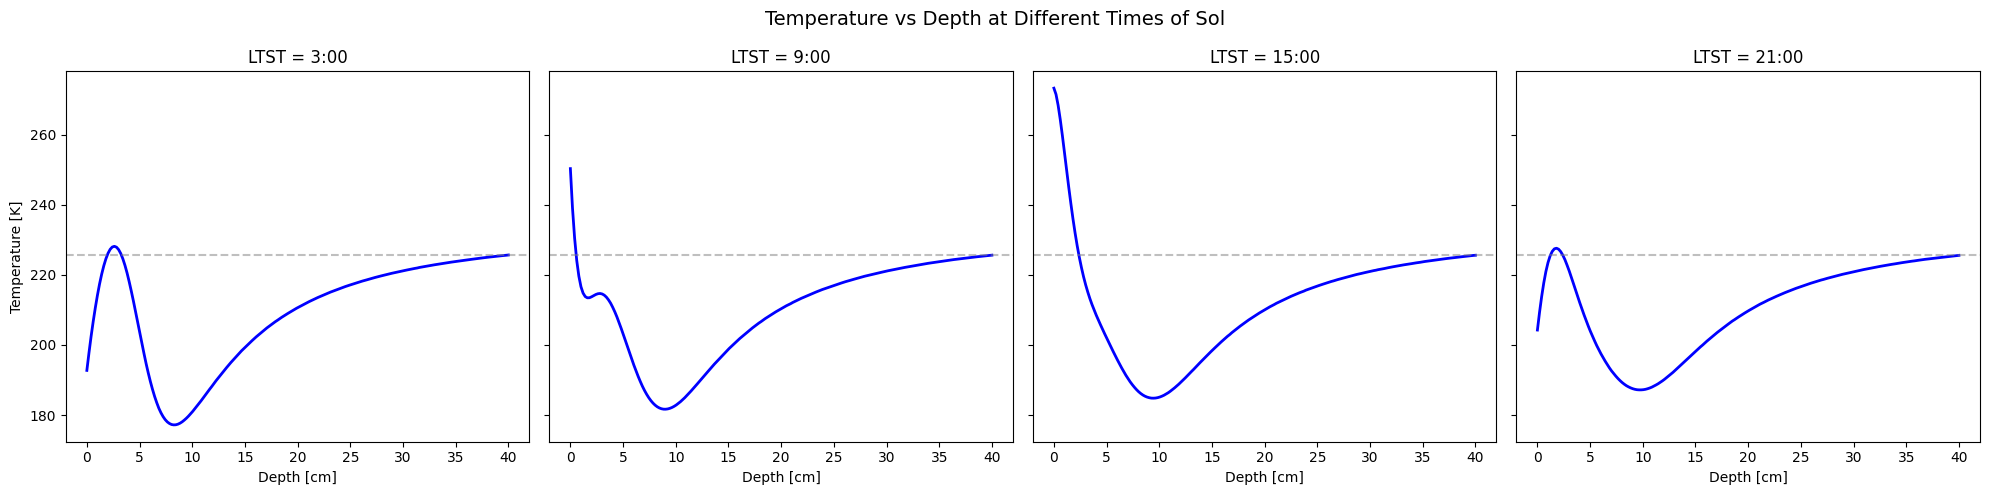

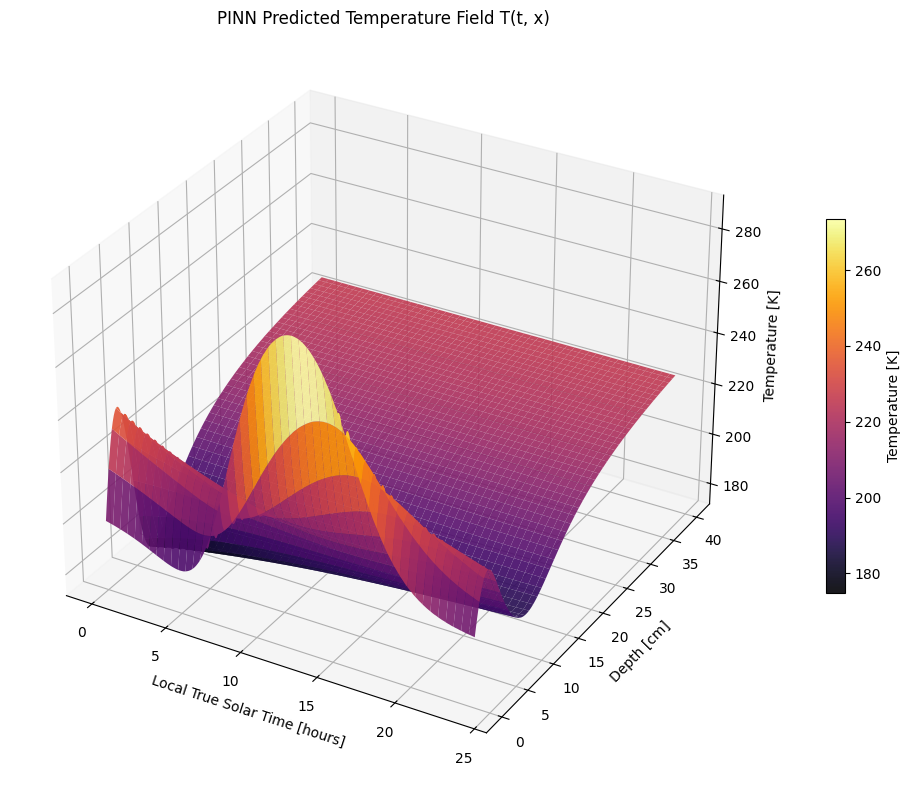

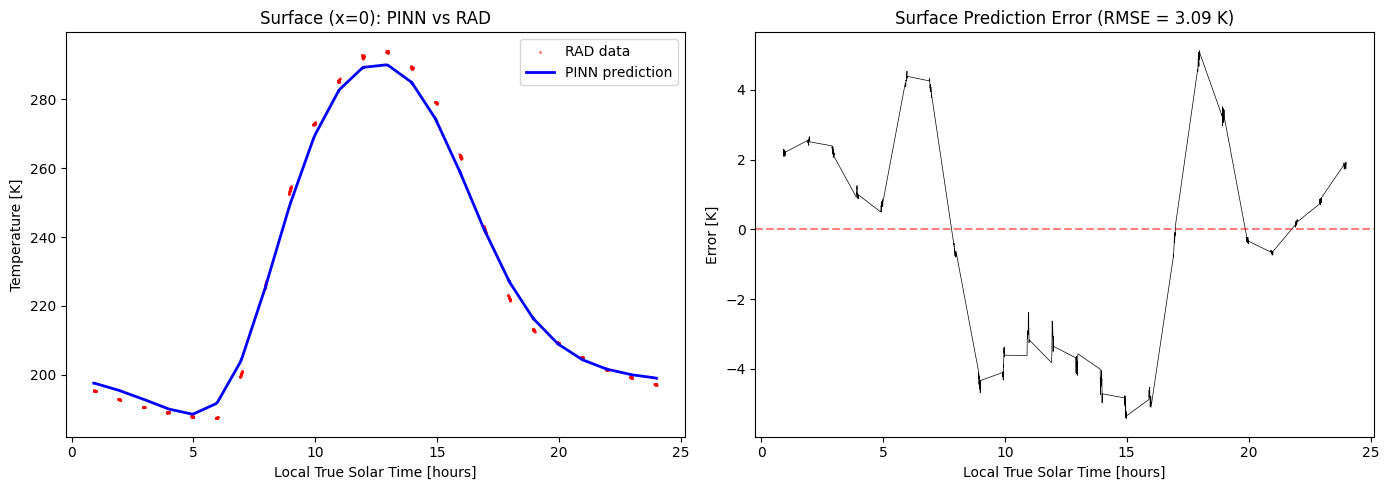

In [3]:
# Temperature vs Depth at four times of day
fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)

hours_to_plot = [3, 9, 15, 21]
depths = jnp.linspace(0, depth, 200)  # 0 to 0.4 m

for idx, hour in enumerate(hours_to_plot):
    t_sec = hour * sol_seconds / 24
    t_norm = normalize_t(t_sec)
    x_norm = normalize_x(depths)
    
    # Build input array
    t_input = jnp.ones_like(x_norm) * t_norm
    tx_input = jnp.stack([t_input, x_norm], axis=-1)
    
    # Predict
    u_pred_norm = network(params, tx_input)
    u_pred = unnormalize_u(u_pred_norm.ravel())
    
    axes[idx].plot(depths * 100, u_pred, 'b-', linewidth=2)  # depth in cm
    axes[idx].set_title(f'LTST = {hour}:00')
    axes[idx].set_xlabel('Depth [cm]')
    axes[idx].axhline(y=avg_bottom_temp, color='gray', linestyle='--', alpha=0.5, label='Bottom BC')
    
axes[0].set_ylabel('Temperature [K]')
plt.suptitle('Temperature vs Depth at Different Times of Sol', fontsize=14)
plt.tight_layout()
plt.show()


# 3D surface plot: T(t, x)
from mpl_toolkits.mplot3d import Axes3D

n_t, n_x = 200, 200
t_grid = jnp.linspace(0, 1, n_t)  # already normalized
x_grid = jnp.linspace(0, 1, n_x)  # already normalized

T_mesh, X_mesh = jnp.meshgrid(t_grid, x_grid)
tx_flat = jnp.stack([T_mesh.ravel(), X_mesh.ravel()], axis=-1)

u_pred_flat = network(params, tx_flat)
u_pred_grid = unnormalize_u(u_pred_flat.reshape(n_x, n_t))

# Convert axes back to physical units for plotting
t_hours = np.linspace(0, 24, n_t)
x_cm = np.linspace(0, depth * 100, n_x)
T_plot, X_plot = np.meshgrid(t_hours, x_cm)

fig = plt.figure(figsize=(14, 8))
ax = fig.add_subplot(111, projection='3d')
surf = ax.plot_surface(T_plot, X_plot, np.array(u_pred_grid), cmap='inferno', alpha=0.9)
ax.set_xlabel('Local True Solar Time [hours]')
ax.set_ylabel('Depth [cm]')
ax.set_zlabel('Temperature [K]')
ax.set_title('PINN Predicted Temperature Field T(t, x)')
fig.colorbar(surf, shrink=0.5, label='Temperature [K]')
plt.tight_layout()
plt.show()


# PINN vs RAD at surface (x=0)
t_surf_norm = normalize_t(jnp.array(ltst_surf))
x_surf_norm = jnp.zeros_like(t_surf_norm)
tx_surf = jnp.stack([t_surf_norm, x_surf_norm], axis=-1)

u_pred_surf = unnormalize_u(network(params, tx_surf).ravel())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ltst_hours_surf = [t * 24 / sol_seconds for t in ltst_surf]

axes[0].scatter(ltst_hours_surf, temp_surf, s=1, c='red', alpha=0.5, label='RAD data')
axes[0].plot(ltst_hours_surf, np.array(u_pred_surf), 'b-', linewidth=2, label='PINN prediction')
axes[0].set_xlabel('Local True Solar Time [hours]')
axes[0].set_ylabel('Temperature [K]')
axes[0].set_title('Surface (x=0): PINN vs RAD')
axes[0].legend()

# Error at surface
error_surf = np.array(u_pred_surf) - np.array(temp_surf)
axes[1].plot(ltst_hours_surf, error_surf, 'k-', linewidth=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', alpha=0.5)
axes[1].set_xlabel('Local True Solar Time [hours]')
axes[1].set_ylabel('Error [K]')
rmse_surf = np.sqrt(np.mean(error_surf**2))
axes[1].set_title(f'Surface Prediction Error (RMSE = {rmse_surf:.2f} K)')

plt.tight_layout()
plt.show()